Project root: c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main
Data directory: c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main\data\processed
Training: (4895, 200) (4895,)
Validation: (1049, 200) (1049,)
Test: (1050, 200) (1050,)
Class weights: {np.int64(0): np.float64(1.8776371308016877), np.int64(1): np.float64(1.317985998922994), np.int64(2): np.float64(0.585246293639407)}


Model: "hotel_review_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,443 (5.03 MB)

 Trainable params: 1,317,443 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6239 - loss: 0.9118
Epoch 1: val_loss improved from None to 0.73654, saving model to c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main\models_saved\gru\gru_model_best.keras

Epoch 1: finished saving model to c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main\models_saved\gru\gru_model_best.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.6239 - loss: 0.9118 - val_accuracy: 0.6606 - val_loss: 0.7365 - learning_rate: 0.0010
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7265 - loss: 0.6398
Epoch 2: val_loss improved from 0.73654 to 0.70210, saving model to c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main\models_saved\gru\gru_model_best.keras

Epoch 2: finished saving model to c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-fee

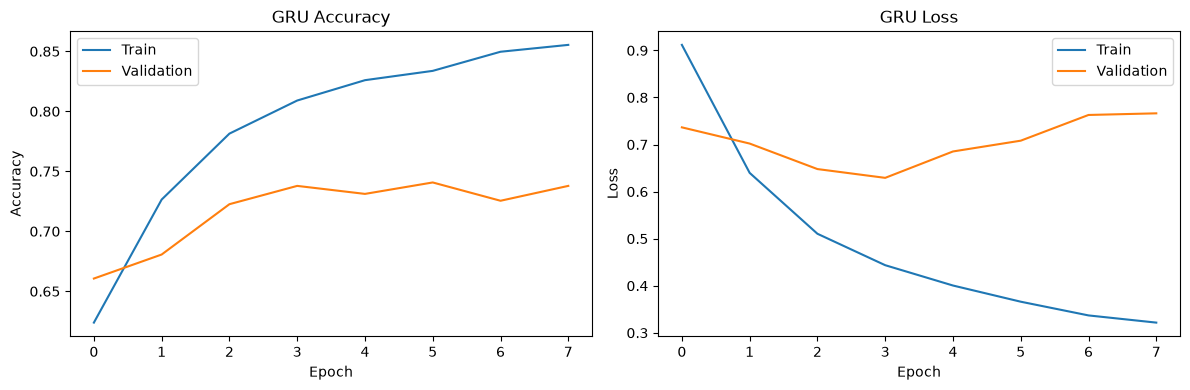

In [5]:
# GRU hotel-review classification
# This notebook uses the shared processed arrays and class weights.
from pathlib import Path
import json
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "processed").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.GRU.gru_model import build_gru_model

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "models_saved" / "gru"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

# Load the common train, validation, and test arrays.
X_train = np.load(DATA_DIR / "X_train_pad.npy")
X_val = np.load(DATA_DIR / "X_val_pad.npy")
X_test = np.load(DATA_DIR / "X_test_pad.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

with open(DATA_DIR / "class_weights.pkl", "rb") as file:
    class_weights = pickle.load(file)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Class weights:", class_weights)

model = build_gru_model()
model.summary()
batch_size = 32
epochs = 30

# Select the best validation-loss epoch and reduce the learning rate when progress stalls.
best_model_path = OUTPUT_DIR / "gru_model_best.keras"
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)
reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

start_time = time.perf_counter()
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_learning_rate, model_checkpoint],
    verbose=1,
)
training_seconds = time.perf_counter() - start_time

# The callback restores the best weights; save that final selected model at the comparison path.
model.save(OUTPUT_DIR / "gru_model.keras")
with open(OUTPUT_DIR / "gru_history.pkl", "wb") as file:
    pickle.dump(history.history, file)

print(f"Training time: {training_seconds:.2f} seconds")
print(f"Best epoch: {int(np.argmin(history.history['val_loss']) + 1)}")

test_start = time.perf_counter()
test_probabilities = model.predict(X_test, batch_size=batch_size, verbose=0)
inference_seconds = time.perf_counter() - test_start
test_predictions = np.argmax(test_probabilities, axis=1)
class_names = ["Poor", "Average", "Good"]

metrics = {
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "precision_macro": float(precision_score(y_test, test_predictions, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_test, test_predictions, average="macro", zero_division=0)),
    "f1_macro": float(f1_score(y_test, test_predictions, average="macro", zero_division=0)),
    "precision_weighted": float(precision_score(y_test, test_predictions, average="weighted", zero_division=0)),
    "recall_weighted": float(recall_score(y_test, test_predictions, average="weighted", zero_division=0)),
    "f1_weighted": float(f1_score(y_test, test_predictions, average="weighted", zero_division=0)),
    "roc_auc_ovr_macro": float(roc_auc_score(y_test, test_probabilities, multi_class="ovr", average="macro")),
    "training_seconds": float(training_seconds),
    "inference_seconds": float(inference_seconds),
    "inference_latency_ms_per_sample": float(inference_seconds / len(X_test) * 1000),
    "throughput_samples_per_second": float(len(X_test) / inference_seconds),
    "parameter_count": int(model.count_params()),
}

report = classification_report(
    y_test,
    test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
print(json.dumps(metrics, indent=2))
print(classification_report(y_test, test_predictions, target_names=class_names, zero_division=0))

confusion = confusion_matrix(y_test, test_predictions)
np.save(OUTPUT_DIR / "gru_confusion_matrix.npy", confusion)
with open(OUTPUT_DIR / "gru_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)
with open(OUTPUT_DIR / "gru_classification_report.json", "w", encoding="utf-8") as file:
    json.dump(report, file, indent=2)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("GRU Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("GRU Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

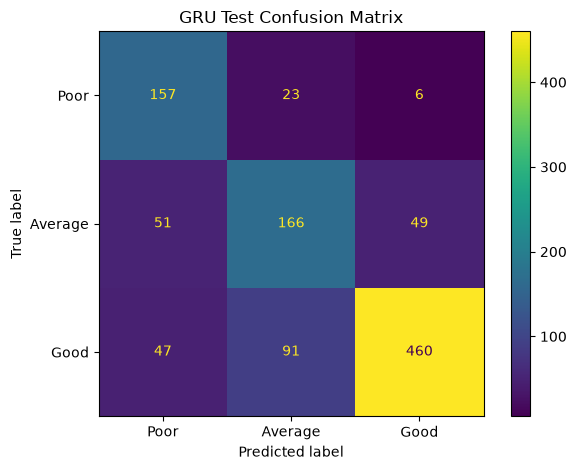

In [4]:
# Display the saved GRU test confusion matrix.
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

confusion = np.load(OUTPUT_DIR / "gru_confusion_matrix.npy")
class_names = ["Poor", "Average", "Good"]

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names,
)
display.plot(cmap="viridis", values_format="d")
plt.title("GRU Test Confusion Matrix")
plt.tight_layout()
plt.show()

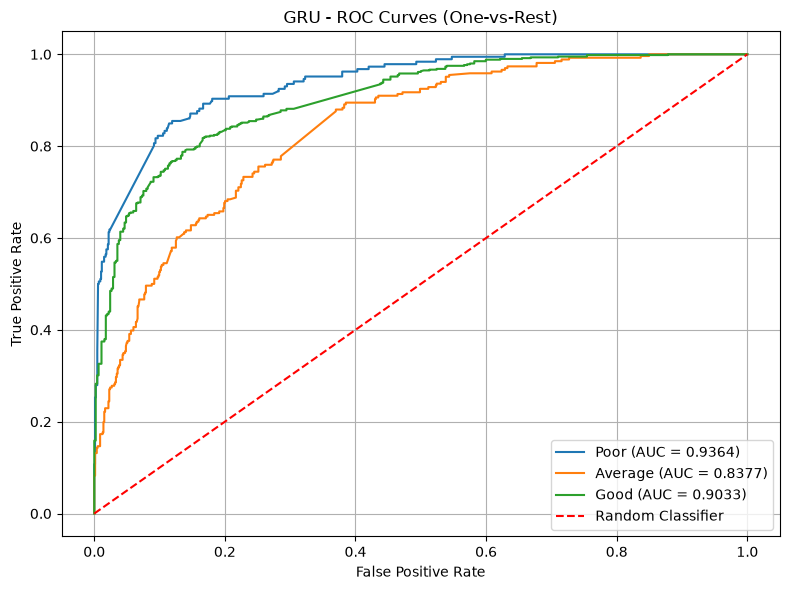

In [6]:
# Plot one-vs-rest ROC curves for the GRU test predictions.
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

y_test_binary = label_binarize(y_test, classes=[0, 1, 2])
roc_probabilities = test_probabilities

plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(class_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        roc_probabilities[:, class_index],
    )
    class_auc = auc(false_positive_rate, true_positive_rate)
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC = {class_auc:.4f})",
    )

plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.title("GRU - ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gru_roc_curves.png", dpi=150)
plt.show()